In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/student_performance.csv")
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [ ]:
conn =sqlite3.connect('student.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count = cursor.fetchone()[0]
print(f"Database 'student.db' created successfully!" )
print(f"Table 'students' has {count} rows")

Database 'student.db' created successfully!
Table 'students' has 30 rows


In [ ]:
def run_query(query, label):
    cursor.execute(query)
    results = cursor.fetchall()
    print(label)
    for row in results:
        print(row)
    return results

query1 = """
SELECT student_id, name, department, math_score, attendance_percentage
FROM students
LIMIT 10
"""
result1= run_query(query1,"Query 1: First 10 students (SELECT + LIMIT)")

Query 1: First 10 students (SELECT + LIMIT)
(1001, 'Aarav Sharma', 'Computer Science', 85, 92)
(1002, 'Priya Patel', 'Computer Science', 76, 87)
(1003, 'Rohit Verma', 'Electronics', 65, 78)
(1004, 'Sneha Reddy', 'Mechanical', 70, 95)
(1005, 'Arjun Nair', 'Computer Science', 92, 90)
(1006, 'Meera Joshi', 'Electronics', 58, 72)
(1007, 'Kiran Kumar', 'Civil', 73, 85)
(1008, 'Divya Singh', 'Computer Science', 88, 96)
(1009, 'Rahul Mishra', 'Mechanical', 62, 68)
(1010, 'Ananya Das', 'Computer Science', 95, 98)


In [ ]:
query2 = """
SELECT name,department, math_score
FROM students
WHERE math_score>90
ORDER BY math_score DESC
"""
result2 = run_query(query2, "Query2: TOP 5 MATH SCORES(ORDER BY DESC)")

Query2: TOP 5 MATH SCORES(ORDER BY DESC)
('Ananya Das', 'Computer Science', 95)
('Tanvi Mehta', 'Computer Science', 93)
('Arjun Nair', 'Computer Science', 92)
('Akanksha Yadav', 'Computer Science', 91)


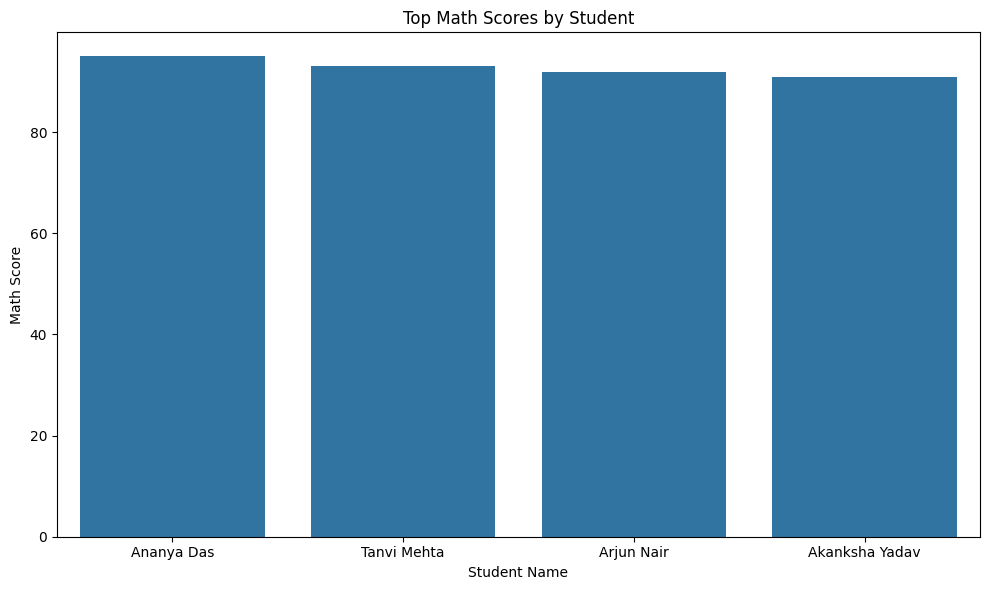

In [ ]:
df_avg_math=pd.DataFrame(result2,columns=['name','department','math_score'])
plt.figure(figsize=(10,6))
sns.barplot(x='name',y='math_score',data=df_avg_math)
plt.title('Top Math Scores by Student')
plt.xlabel('Student Name')
plt.ylabel('Math Score')
plt.tight_layout()
plt.show()

In [ ]:
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the DataFrame.")
else:
    print("\nColumns with missing values are listed above.")


Missing values per column:
Series([], dtype: int64)
No missing values found in the DataFrame.


In [ ]:
API_KEY='93535d167503396f377d6ea46d4f3d8a'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES=['Mumbai', 'Delhi','Banglore','Chennai', 'Hydrabad','Kolkata','Pune','Jaipur']
print(f'API configured for{len(CITIES)} cities')
print(f'cities:{CITIES}')
print('\nIMPORTANT:''93535d167503396f377d6ea46d4f3d8a')

API configured for8 cities
cities:['Mumbai', 'Delhi', 'Banglore', 'Chennai', 'Hydrabad', 'Kolkata', 'Pune', 'Jaipur']

IMPORTANT:93535d167503396f377d6ea46d4f3d8a


In [ ]:
import requests

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrics, or None on failure.
  """

  params = {
      'q': city,
      'appid': api_key,
      'units': 'metric'
  }

  try:
    response = requests.get(BASE_URL, params=params, timeout=10)

    if response.status_code == 200:
      data = response.json()

      return {
          'city': city,
          'temperature': round(data['main']['temp'], 1),
          'feels_like': round(data['main']['feels_like'], 1),
          'humidity': data['main']['humidity'],
          'condition': data['weather'][0]['description'],
          'visibility': data['visibility']
      }
    else:
      print(f'ERROR {response.status_code} for {city}:{response.json().get("message")}')
      return None
  except requests.exceptions.RequestException as e:
    print(f'Request failed for {city}: {e}')
    return None


weather_records = []
print('Calling Weather API....')
for city in CITIES:
  print(f'Fetching: {city}...', end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record["temperature"]}°C')
  else:
    print('Failed')

import pandas as pd
df_weather = pd.DataFrame(weather_records)
display(df_weather.head())

Calling Weather API....
Fetching: Mumbai...31.6°C
Fetching: Delhi...39.8°C
Fetching: Banglore...ERROR 404 for Banglore:city not found
Failed
Fetching: Chennai...37.8°C
Fetching: Hydrabad...ERROR 404 for Hydrabad:city not found
Failed
Fetching: Kolkata...38.0°C
Fetching: Pune...34.6°C
Fetching: Jaipur...38.4°C


,city,temperature,feels_like,humidity,condition,visibility
0,Mumbai,31.6,38.6,73,clear sky,10000
1,Delhi,39.8,39.1,20,overcast clouds,10000
2,Chennai,37.8,44.8,48,overcast clouds,10000
3,Kolkata,38.0,42.6,38,broken clouds,10000
4,Pune,34.6,37.1,42,few clouds,10000


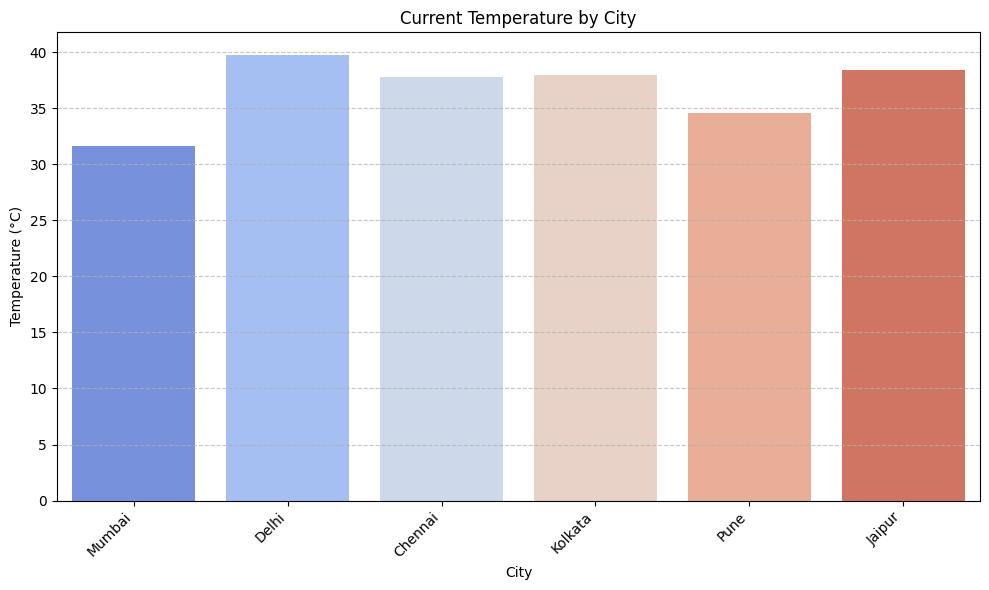

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='city', y='temperature', data=df_weather, palette='coolwarm', hue='city', legend=False)
plt.title('Current Temperature by City')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


#SparkSession
spark=SparkSession.builder \
.appName('Day4_BigData_Sales')\
.config('spark.sql.adaptive.enabled','true')\
.getOrCreate()


print(f'Spark Session : {spark.version}')

Spark Session : 4.0.2


## Basic Machine Learning Model

Let's train a simple regression model to predict `math_score` based on other student attributes.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

In [ ]:
# Define features (X) and target (y)
# Drop student_id, name, and the target variable itself from features
features = df.drop(columns=['student_id', 'name', 'math_score'])
target = df['math_score']

# Handle categorical features using one-hot encoding
X = pd.get_dummies(features, columns=['gender', 'department', 'city'], drop_first=True)
y = target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (24, 35)
Testing features shape: (6, 35)
Training target shape: (24,)
Testing target shape: (6,)


### Model Training

We will use a RandomForestRegressor, a powerful and flexible machine learning algorithm, to predict the `math_score`.

In [ ]:
# Initialize and train the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### Model Evaluation

Now, let's evaluate the model's performance on the test set using Mean Absolute Error (MAE) and R-squared ($R^2$).

*   **Mean Absolute Error (MAE)**: The average of the absolute differences between predictions and actual values. It measures the average magnitude of the errors in a set of predictions, without considering their direction.
*   **R-squared ($R^2$)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher $R^2$ indicates a better fit for the model.

Mean Absolute Error (MAE): 3.48
R-squared (R2): 0.88


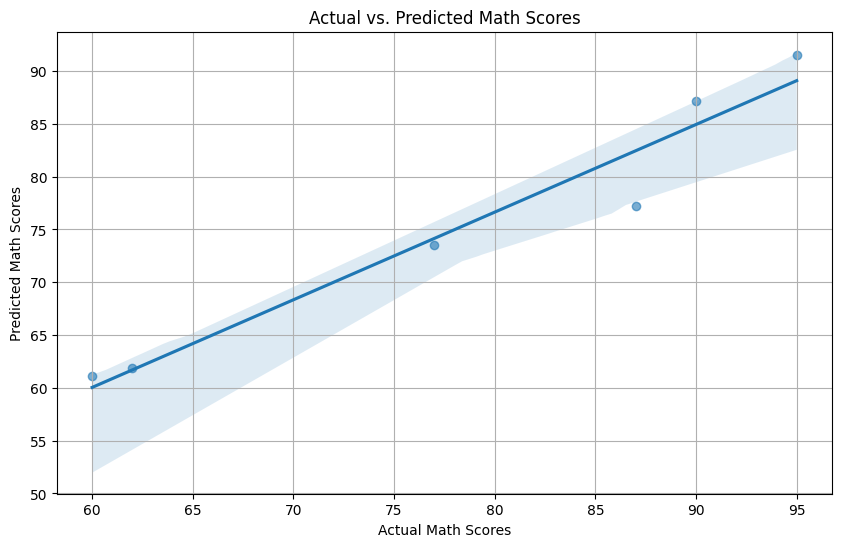

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Optionally, visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6})
plt.xlabel('Actual Math Scores')
plt.ylabel('Predicted Math Scores')
plt.title('Actual vs. Predicted Math Scores')
plt.grid(True)
plt.show()

In [ ]:
!pip install groq
import sqlite3
import pandas as pd
import os
from groq import Groq
import re
print("All libraries r imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 8.2 MB/s eta 0:00:00
All libraries r imported successfully!


In [ ]:
client = Groq(api_key="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")
GROQ_API_KEY="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"
os.environ["GROQ_API_KEY"]=GROQ_API_KEY
MODEL="llama-3.1-8b-instant"
print("Groq client initaliezd successfully")
print(f"Using model:{MODEL}")

Groq client initaliezd successfully
Using model:llama-3.1-8b-instant


In [ ]:
def get_schema(conn, table_name="students"):
  """
  This function reads the structure of a database table. It returns information about each column: name and data
  Parameters:
  conn:The SQLite connection object (our link to the database)
  table_name:The name of the table to inspect
  Returns:
  A formatted string describing the table strucutre
  """
  cursor=conn.cursor()
  cursor.execute(f"PRAGMA table_info({table_name})")
  columns=cursor.fetchall()

  schema_lines=[f"Table:{table_name}"]
  for col in columns:
    schema_lines.append(f"- {col[1]} ({col[2]})")

  # Get sample rows after all columns are added to schema_lines
  cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
  sample_rows=cursor.fetchall()
  schema_lines.append("\nSample rows (first 3):")
  for row in sample_rows:
    schema_lines.append(f"{row}")

  return "\n".join(schema_lines)

schema = get_schema(conn)
print(schema)

Table:students
- student_id (INTEGER)
- name (TEXT)
- age (INTEGER)
- gender (TEXT)
- department (TEXT)
- semester (INTEGER)
- math_score (INTEGER)
- science_score (INTEGER)
- english_score (INTEGER)
- programming_score (INTEGER)
- attendance_percentage (INTEGER)
- city (TEXT)
- admission_year (INTEGER)

Sample rows (first 3):
(1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
(1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
(1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [ ]:
def generate_sql(user_question,schema_text,client,model):
  """
  Sends the user's question and database schema to the Groq
  The LLM generates a SQL query that answers the question
  Parameters:
  user_question

  Returns:
  A string containing the SQL query
  """
  system_prompt=f"""You are an expert SQL assistant.
  You are connected to a SQLite database with the following schema:
  {schema_text}
  Rules you must follow:
  1. Generate ONLY a valid SQLite SQL query.
  2. Do not include any explanation or text — only the SQL query.
  3. Do not use markdown code blocks. Return the raw SQL only.
  4. The table name is: students
  5. Only use column names that exist in the schema above.
  6. Use single quotes for string values in WHERE clauses (example: WHERE subject = 'Programming').
  7. If the user asks for top N, use ORDER BY marks DESC LIMIT N.
  """
  response=client.chat.completions.create(
      model=model,
      messages=[
          {"role":"system","content":system_prompt},
          {"role":"user","content":user_question}
      ],
      temperature=0.0
  )
  sql_query=response.choices[0].message.content.strip()
  return sql_query

question ="show me all female students"
print(f"Question:{question}")
print("\n Generating SQL...")
sql=generate_sql(question,schema, client, MODEL)
print(f"\nGenerated SQL:\n{sql}")

Question:show me all female students

 Generating SQL...

Generated SQL:
SELECT * FROM students WHERE gender = 'Female'


In [ ]:
def execute_sql(sql_query, conn):
  """
  Cleans the AI-generated SQL and executes it to the SQlite database.
  Returns the results as a pandas Dataframe.
  Parameters:
  sql_query: The SQL string generatedd by the LLM
  conn: The SQlite database connection
  Returns:
  A pandas DataFrame witht the query results, or an error message
  """
  clean_sql=sql_query.strip()
  clean_sql= re.sub(r'```sql\s*', '',clean_sql)
  clean_sql=clean_sql.strip()
  try:
    result_df=pd.read_sql_query(clean_sql, conn)
    return result_df, None
  except Exception as e:
    return None, str(e)

In [ ]:
result_df, error = execute_sql(sql, conn)
if error:
  print(f"Error executing SQL: {error}")
else:
  print("SQL executed successfully. Results:")
  print(result_df)

SQL executed successfully. Results:
    student_id            name  age  gender        department  semester  \
0         1002     Priya Patel   20  Female  Computer Science         2   
1         1004     Sneha Reddy   20  Female        Mechanical         2   
2         1006     Meera Joshi   20  Female       Electronics         2   
3         1008     Divya Singh   19  Female  Computer Science         2   
4         1010      Ananya Das   19  Female  Computer Science         2   
5         1012     Pooja Gupta   19  Female             Civil         2   
6         1014   Kavya Nambiar   20  Female        Mechanical         2   
7         1016    Ritu Agarwal   20  Female       Electronics         2   
8         1018  Swati Kulkarni   19  Female  Computer Science         2   
9         1020    Nisha Kapoor   19  Female  Computer Science         2   
10        1022     Tanvi Mehta   19  Female  Computer Science         2   
11        1024   Preeti Saxena   20  Female        Mechanical   

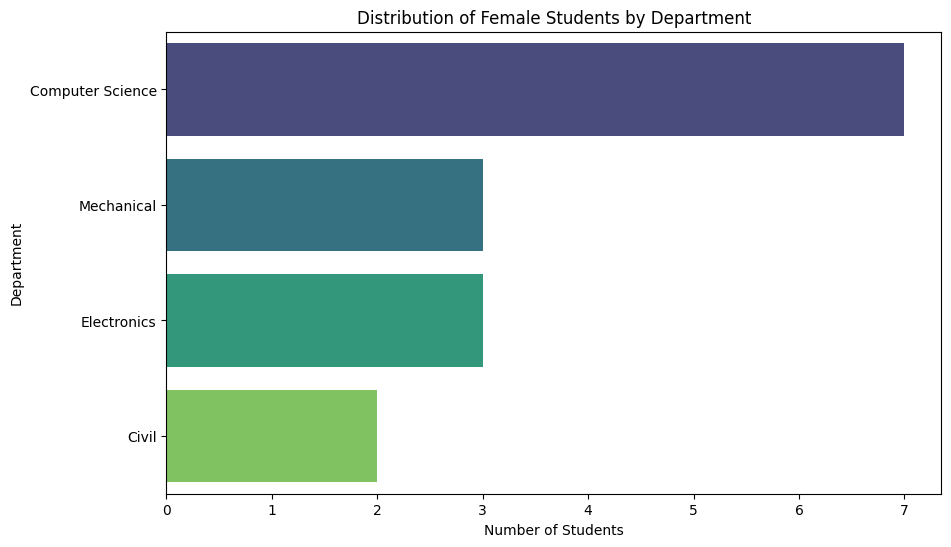

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=result_df, y='department', palette='viridis', order=result_df['department'].value_counts().index)
plt.title('Distribution of Female Students by Department')
plt.xlabel('Number of Students')
plt.ylabel('Department')
plt.show()

In [ ]:
def text_to_sql_agent(user_question, conn, client, model, verbose=True):
  """
  the main AI agent function.
  takes a user question in plain English and returns database results.

  This is the complete workflow:
  1.Get database schema
  2.Generate SQL using Groq LLM
  3.Execute SQL on the database
  4.Return results to the user
  """
  print(f"USer Question: {user_question}")
  print("="*60)
  if verbose:
    print("\n[STEP 1] Reading database schema...")
  schema_text=get_schema(conn)
  if verbose:
    print("Schema loaded successfully")
  if verbose:
    print("\n[STEP 2] Generating SQL query with Groq LLM...")
  generated_sql=generate_sql(user_question, schema_text, client, model)
  if verbose:
    print(f"SQL generated successfully:\n {generated_sql}")
  if verbose:
    print("\n[STEP 3] Executing SQL query...")
  result_df, error=execute_sql(generated_sql,conn)
  if error:
    print(f"SQL Execution Error: {error}")
    return None, generated_sql
  if verbose:
    print(f"\n[STEP 4] Query returned{len(result_df)} row(s)")
    print("\nRESULTS:")
    print("-"*40)
    print(result_df.to_string(index=False))
  print("="*60)
  return result_df, generated_sql

In [ ]:
# Example usage of the text_to_sql_agent function with a new question
new_question = "What is the average math score of female students in Computer Science?"

new_results, new_sql_query = text_to_sql_agent(new_question, conn, client, MODEL)

print(f"\nGenerated SQL: {new_sql_query}")
print(f"\nQuery Results:\n{new_results.to_string(index=False)}")

USer Question: What is the average math score of female students in Computer Science?

[STEP 1] Reading database schema...
Schema loaded successfully

[STEP 2] Generating SQL query with Groq LLM...
SQL generated successfully:
 SELECT AVG(math_score) FROM students WHERE gender = 'Female' AND department = 'Computer Science'

[STEP 3] Executing SQL query...

[STEP 4] Query returned1 row(s)

RESULTS:
----------------------------------------
 AVG(math_score)
       87.428571

Generated SQL: SELECT AVG(math_score) FROM students WHERE gender = 'Female' AND department = 'Computer Science'

Query Results:
 AVG(math_score)
       87.428571


In [ ]:
# Example usage of the text_to_sql_agent function
question = "show me all students with a programming score greater than 90"

results, sql_query = text_to_sql_agent(question, conn, client, MODEL)

print(f"\nGenerated SQL: {sql_query}")
print(f"\nQuery Results:\n{results.to_string(index=False)}")

USer Question: show me all students with a programming score greater than 90

[STEP 1] Reading database schema...
Schema loaded successfully

[STEP 2] Generating SQL query with Groq LLM...
SQL generated successfully:
 SELECT * FROM students WHERE programming_score > 90

[STEP 3] Executing SQL query...

[STEP 4] Query returned7 row(s)

RESULTS:
----------------------------------------
 student_id           name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage    city  admission_year
       1001   Aarav Sharma   19   Male Computer Science         2          85             78             72                 91                     92  Mumbai            2023
       1005     Arjun Nair   19   Male Computer Science         2          92             88             81                 95                     90   Kochi            2023
       1008    Divya Singh   19 Female Computer Science         2          88             9

In [ ]:
def generate_natural_language_summary(dataframe, user_context, client, model):
  """
  Generates a natural language summary of a pandas DataFrame using the Groq LLM.

  Parameters:
  dataframe (pd.DataFrame): The DataFrame to summarize.
  user_context (str): Additional context or question from the user.
  client: The Groq client object.
  model (str): The Groq model to use.

  Returns:
  str: A natural language summary of the DataFrame.
  """
  df_head = dataframe.head().to_string()
  df_info = dataframe.info()
  df_describe = dataframe.describe().to_string()

  # Get schema again for clarity on column types
  schema_text = get_schema(conn)

  prompt = f"""You are an expert data analyst. Your task is to summarize the following pandas DataFrame into natural language. Focus on key insights and distributions.

  Here is the user's original context/question: {user_context}

  The database schema is as follows:
  {schema_text}

  Here is the head of the DataFrame:
  {df_head}

  Here is descriptive statistics of the DataFrame:
  {df_describe}

  Provide a concise summary in natural language. Do not include any code or markdown code blocks.
  """

  response = client.chat.completions.create(
      model=model,
      messages=[
          {"role": "system", "content": prompt},
          {"role": "user", "content": f"Summarize the data for the question: {user_context}"}
      ],
      temperature=0.0
  )
  return response.choices[0].message.content.strip()

# Assuming result_df is the DataFrame you want to summarize
summary_context = "Distribution of female students by department as shown in the bar chart."
natural_language_summary = generate_natural_language_summary(result_df, summary_context, client, MODEL)

print("Natural Language Summary of Female Students by Department:")
print(natural_language_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             15 non-null     int64 
 1   name                   15 non-null     object
 2   age                    15 non-null     int64 
 3   gender                 15 non-null     object
 4   department             15 non-null     object
 5   semester               15 non-null     int64 
 6   math_score             15 non-null     int64 
 7   science_score          15 non-null     int64 
 8   english_score          15 non-null     int64 
 9   programming_score      15 non-null     int64 
 10  attendance_percentage  15 non-null     int64 
 11  city                   15 non-null     object
 12  admission_year         15 non-null     int64 
dtypes: int64(9), object(4)
memory usage: 1.7+ KB
Natural Language Summary of Female Students by Department:
The distribution of fem